In [1]:
from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

import cv2
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np
import imutils
from skimage.feature import blob_dog, blob_log
from skimage.transform import rotate


In [2]:
# original_img = cv2.imread('cropped_image.png', cv2.IMREAD_GRAYSCALE)
original_img = cv2.imread('POSCAR_Pt_6layer_yuxin_edit_mirrrored_100slc_850x850_12nmDefocus.png', cv2.IMREAD_GRAYSCALE)
expt_img = cv2.imread('Exp_img.jpg', cv2.IMREAD_GRAYSCALE)


In [3]:
original_img.shape

(369, 369)

In [4]:
expt_img.shape

(116, 155)

In [5]:
def crop_img(dr_probe_img):
    simulated_blobs = blob_dog(dr_probe_img, max_sigma=30, threshold=0.1)
    simulated_central_point = np.mean(simulated_blobs, axis=0)[:2].astype(int)
    # Specify the central point (201, 191)
    center_x, center_y = simulated_central_point[1],simulated_central_point[0]
    # Specify the desired width and height of the cropped region
    desired_width = 155  # For example
    desired_height = 116  # Corresponding to 4:3 aspect ratio
    # Calculate the top-left corner coordinates of the cropped region
    start_x = max(0, center_x - desired_width // 2)
    start_y = max(0, center_y - desired_height // 2)
    # Calculate the width and height of the actual cropped region
    actual_width = min(desired_width, dr_probe_img.shape[1] - start_x)
    actual_height = min(desired_height, dr_probe_img.shape[0] - start_y)
    # Perform the cropping
    cropped_image = dr_probe_img[start_y:start_y + actual_height, start_x:start_x + actual_width]
    # cv2.imwrite("cropped_image.png", cropped_image)
    plt.imshow(cropped_image,cmap='gray')
    plt.axis('off')
    plt.show()
    return cropped_image, start_x,start_y, actual_width, actual_height

In [6]:
def zoom_img(img,zoom_factor):
    zoomed_img = img[round(0.5*img.shape[0]*(zoom_factor-1)/zoom_factor):round(0.5*img.shape[0]*(zoom_factor+1)/zoom_factor),round(0.5*img.shape[1]*(zoom_factor-1)/zoom_factor):round(0.5*img.shape[1]*(zoom_factor+1)/zoom_factor)]
    zoomed_img = cv2.resize(zoomed_img,(img.shape[1],img.shape[0]))
    return zoomed_img

In [7]:
def translate_img(img,delta_x,delta_y):
    height, width = img.shape[:2]

    # Move the first 5 pixels along the x-axis to the end of the image
    shifted_image_x = np.concatenate((img[:, delta_x:], img[:, :delta_x]), axis=1)

    # Move the first 7 pixels along the y-axis to the end of the image
    shifted_image_xy = np.concatenate((shifted_image_x[delta_y:], shifted_image_x[:delta_y]), axis=0)
    return shifted_image_xy


In [8]:
def rotate_img(img,angle):
    height, width = img.shape[:2]
    # Calculate the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2), angle, 1)
    # Perform the rotation
    rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height),borderValue=int(img[0][0]))
    return rotated_img

In [9]:
initial_x0 = [1.01,1,1,1. ]
bounds_x0 = (
    (0.8,1.2),
    (-15,15),
    (-15,15),
    (-5.0,5.0)
)
def evaluate_x0(x0,*args):
    zoom_factor = x0[0]
    delta_x = int(x0[1])
    delta_y = int(x0[2])
    angle = x0[3]
    
    img,exp_img=args
    # modify img
    zoomed_img = zoom_img(img,zoom_factor=zoom_factor)
    translated_img = translate_img(zoomed_img,delta_x,delta_y)
    rotated_img = rotate_img(translated_img,angle)
    # calc mismatch = 1-ssim
    (ssim_value, diff) = ssim(rotated_img, exp_img, full=True)
    # print(x0)
    # print(f'zoom_factor:{zoom_factor}, delta_x:{delta_x},delta_y:{delta_y},angle:{angle},mismatch:{1-ssim_value} ')
    return 1-ssim_value

In [11]:
# Define your callback function
def callbackF(xk, convergence):
    print(f"Iteration: {len(callbackF.iterations)}, Best solution: {xk}, Convergence: {convergence}")
    callbackF.iterations.append(xk)
    callbackF.values.append(evaluate_x0(xk))



In [25]:
# # constraint = LinearConstraint([[0, 1, 0], [0, 0, 1]], [-5, -5], [5, 5], keep_feasible=True)  # y_int and z_int are integers

# print  ('{0:4s}   {1:9s}   {2:9s}   {3:9s}   {4:9s}   {5:9s}'.format('Iter', ' X1', ' X2', ' X3', ' X4', 'f(X)')   )

# # [xopt, fopt, gopt, Bopt, func_calls, grad_calls, warnflg] = \
# callbackF.iterations, callbackF.values = [],[]
# res = minimize(evaluate_x0,
#             initial_x0,
#             method='trust-constr',
#             bounds=bounds_x0,
#             # constraints=constraint,
#             callback=callbackF,
#             options={'maxiter':10000,'disp':True}
#             )

# plt.plot(callbackF.values)
# plt.xlabel('Iteration')
# plt.ylabel('Mismatch Value')
# plt.title('Minimize Optimization')

Iter    X1          X2          X3          X4         f(X)     


ValueError: not enough values to unpack (expected 2, got 0)

In [13]:
type((original_img,expt_img))

tuple

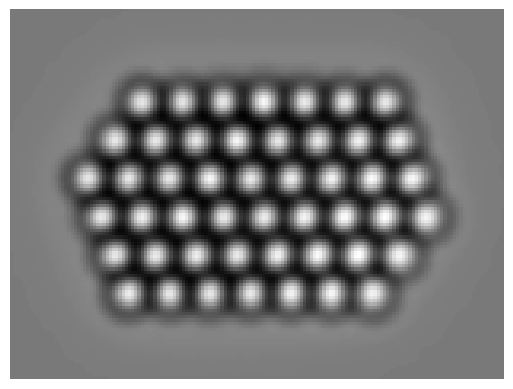

differential_evolution step 1: f(x)= 0.5814337972272235
Iteration: 0, Best solution: [ 1.09771632 12.         -1.          3.65559678], Convergence: 0.14019138680140894


ValueError: not enough values to unpack (expected 2, got 0)

In [16]:
from scipy.optimize import differential_evolution
# Initialize an empty list to store the iterations
callbackF.iterations, callbackF.values = [],[]
additional_args = tuple((original_img,expt_img,))
cropped_image, start_x,start_y, actual_width, actual_height = crop_img(original_img)
res = differential_evolution(evaluate_x0,bounds=bounds_x0, args=(cropped_image,expt_img,),integrality=[0,1,1,0],callback=callbackF,disp=True)

Text(0.5, 1.0, 'Differential Evolution Optimization')

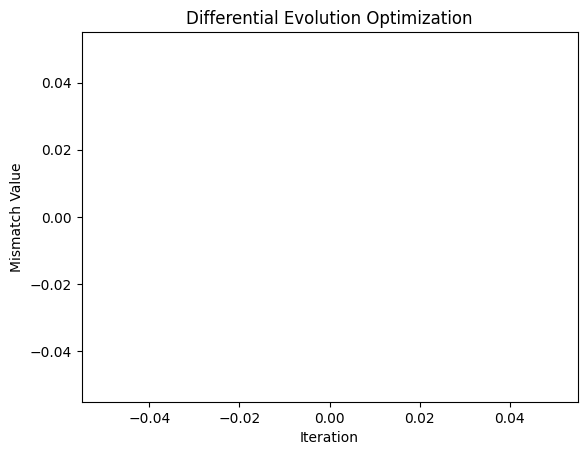

In [24]:
plt.plot(callbackF.values)
plt.xlabel('Iteration')
plt.ylabel('Mismatch Value')
plt.title('Differential Evolution Optimization')

In [18]:
type(plt)

module

In [9]:
zoomed_img = zoom_img(original_img,zoom_factor=res.x[0])
translated_img = translate_img(zoomed_img,int(res.x[1]),int(res.x[2]))
rotated_img = rotate_img(translated_img,res.x[3])

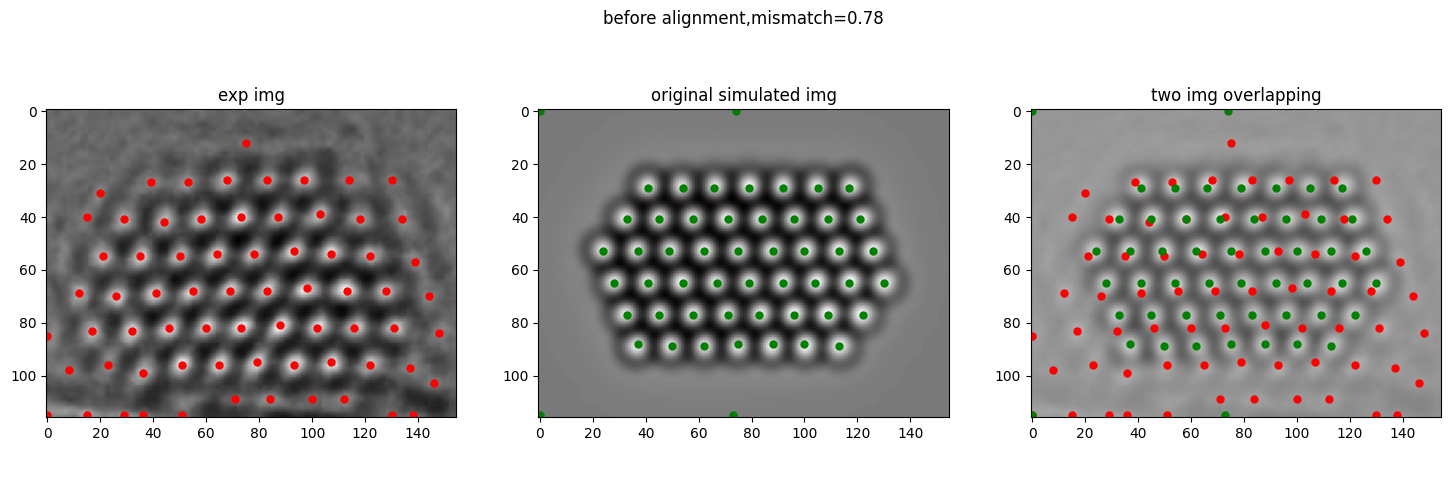

In [10]:
# overlap exp img and simulated img together and see how their blobs overlap
experimental_blobs = blob_dog(exp_img, max_sigma=30, threshold=0.04)

# Detect blobs in the simulated image using Difference of Gaussian (DoG)
simulated_blobs = blob_dog(original_img, max_sigma=30, threshold=0.04)

plt.figure(figsize=(18, 6))
plt.title(f'before alignment,mismatch={round(1-ssim(original_img, exp_img, full=True)[0],2)}')
plt.axis('off')
plt.subplot(1, 3, 1)
plt.title('exp img')
plt.imshow(exp_img, cmap='gray')
for blob in experimental_blobs:
    y, x, _ = blob
    plt.plot(x, y,'ro', markersize=5)  # Red points for experimental atoms

# Plot simulated image
plt.subplot(1, 3, 2)
plt.title('original simulated img')
plt.imshow(original_img, cmap='gray')
for blob in simulated_blobs:
    y, x, _ = blob
    plt.plot(x, y, 'go', markersize=5)  # Green points for simulated atoms

# Plot rotated simulated image
plt.subplot(1, 3, 3)
plt.title('two img overlapping')
plt.imshow(exp_img, cmap='gray',alpha=0.5)
for blob in experimental_blobs:
    y, x, _ = blob
    plt.plot(x, y,'ro', markersize=5)  # Red points for experimental atoms

plt.imshow(original_img, cmap='gray',alpha=0.5)
for blob in simulated_blobs:
    y, x, _ = blob
    plt.plot(x, y, 'go', markersize=5)  # Green points for simulated atoms


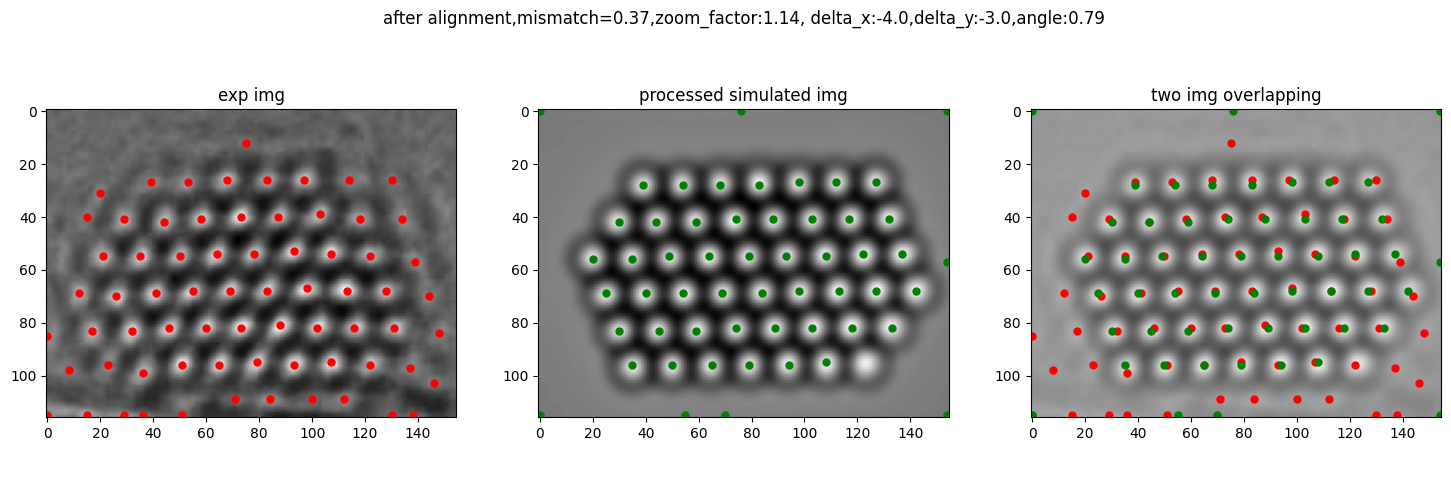

In [11]:
# overlap exp img and simulated img together and see how their blobs overlap
experimental_blobs = blob_dog(exp_img, max_sigma=30, threshold=0.04)

# Detect blobs in the simulated image using Difference of Gaussian (DoG)
simulated_blobs = blob_dog(rotated_img, max_sigma=30, threshold=0.04)

plt.figure(figsize=(18, 6))
plt.title(f'after alignment,mismatch={round(1-ssim(rotated_img, exp_img, full=True)[0],2)},zoom_factor:{round(res.x[0],2)}, delta_x:{res.x[1]},delta_y:{res.x[2]},angle:{round(res.x[3],2)}')
plt.axis('off')
plt.subplot(1, 3, 1)
plt.title('exp img')
plt.imshow(exp_img, cmap='gray')
for blob in experimental_blobs:
    y, x, _ = blob
    plt.plot(x, y,'ro', markersize=5)  # Red points for experimental atoms

# Plot simulated image
plt.subplot(1, 3, 2)
plt.title('processed simulated img')
plt.imshow(rotated_img, cmap='gray')
for blob in simulated_blobs:
    y, x, _ = blob
    plt.plot(x, y, 'go', markersize=5)  # Green points for simulated atoms

# Plot rotated simulated image
plt.subplot(1, 3, 3)
plt.title('two img overlapping')
plt.imshow(exp_img, cmap='gray',alpha=0.5)
for blob in experimental_blobs:
    y, x, _ = blob
    plt.plot(x, y,'ro', markersize=5)  # Red points for experimental atoms

plt.imshow(rotated_img, cmap='gray',alpha=0.5)
for blob in simulated_blobs:
    y, x, _ = blob
    plt.plot(x, y, 'go', markersize=5)  # Green points for simulated atoms



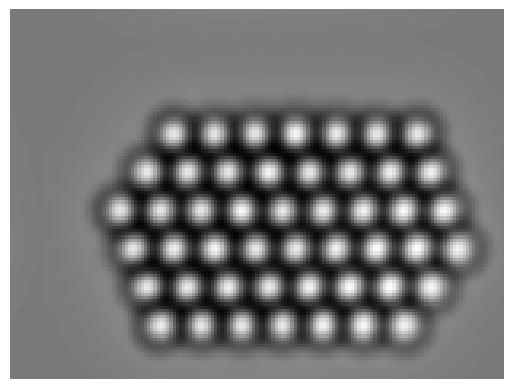

In [15]:
shifted_image_xy = translate_img(original_img,delta_x=-10,delta_y=-10)
plt.imshow(shifted_image_xy,cmap='gray')
plt.axis('off')
plt.show()

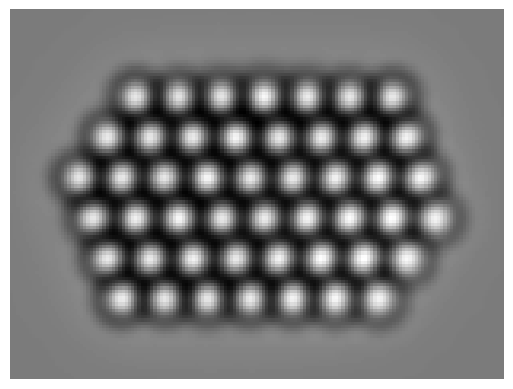

In [8]:
zoomed_img = zoom_img(original_img,zoom_factor=1.05)
plt.imshow(zoomed_img,cmap='gray')
plt.axis('off')
plt.show()

In [41]:
# Define the objective function to minimize
def objective_function(params):
    x_float, y_int, z_int = params
    # Your objective function here
    return x_float**2 + y_int**2 + z_int**2  # Example objective function

# Define the initial guess
initial_guess = [0.0, 0, 0]

# Define the custom constraint for the integer parameters
constraint = LinearConstraint([[0, 1, 0], [0, 0, 1]], [0, 0], [0, 0], keep_feasible=True)  # y_int and z_int are integers

# Use the minimize function with the custom constraint
result = minimize(objective_function, initial_guess, constraints=constraint)

# Extract the optimized parameters
optimized_params = result.x

print("Optimized parameters:", optimized_params)

Optimized parameters: [0. 0. 0.]


/home/yuxin.chang/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:640: OptimizeWarning: Constraint option `keep_feasible` is ignored by this method.
  constraints = standardize_constraints(constraints, x0, meth)


In [43]:
result

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0
       x: [ 0.000e+00  0.000e+00  0.000e+00]
     nit: 1
     jac: [ 1.490e-08  1.490e-08  1.490e-08]
    nfev: 4
    njev: 1